In [2]:
# prompt: read excel file with a specific sheet.

import pandas as pd

# Install openpyxl if you haven't already
#!pip install openpyxl

# Replace 'your_file.xlsx' with the actual filename
# Replace 'Sheet1' with the name of the sheet you want to read
df = pd.read_excel('/content/sample_data/L12 Book Regression.xlsx', sheet_name='College')

# Now you can work with the DataFrame 'df'
print(df.head())


                              School  Earnings   Cost  Grad  Debt  City
0                 St. Ambrose C (NC)     44800  22920    62    88     1
1        Albion College (Albion, MI)     45100  23429    73    92     0
2     Alfred University (Alfred, NY)     42300  19567    63    87     0
3  Allegheny College (Meadville, PA)     49200  25147    78    92     0
4        Beloit College (Beloit, WI)     37900  21979    78    93     1


In [3]:
# prompt: regress with output as Earnings, give report for the performance, joint and individual test.

import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load the data (assuming you've already loaded it into 'df')
# ... (your existing code to load the data) ...

# Define the dependent and independent variables
dependent_variable = 'Earnings'
independent_variables = ['Cost', 'Grad', 'Debt', 'City']  # Replace with your actual independent variables

# Create the regression formula
formula = f"{dependent_variable} ~ {' + '.join(independent_variables)}"

# Fit the OLS model
model = smf.ols(formula, data=df).fit()

# Print the regression summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     20.87
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           7.56e-13
Time:                        12:53:32   Log-Likelihood:                -1164.1
No. Observations:                 116   AIC:                             2338.
Df Residuals:                     111   BIC:                             2352.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept       1e+04   7634.334      1.311      0.1

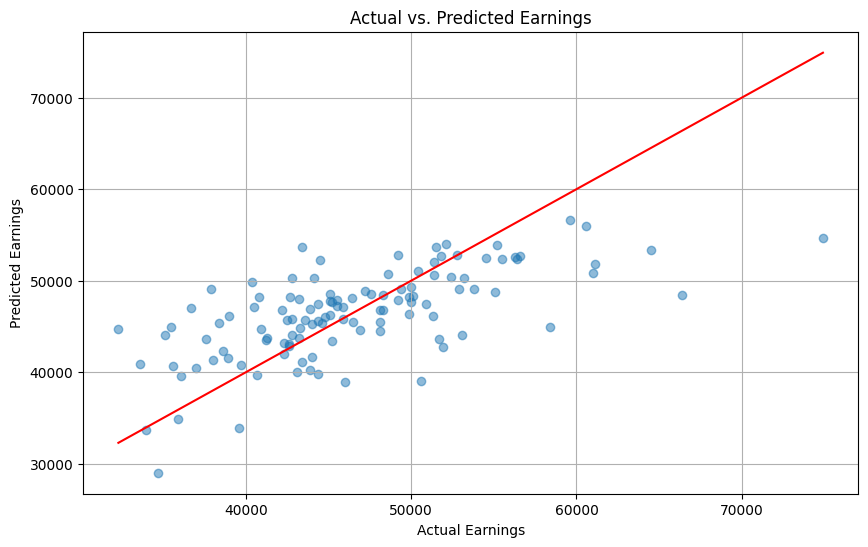

In [4]:
# prompt: Jus plot the dependent variable compared with the regressed result.

import matplotlib.pyplot as plt

# Predict the dependent variable using the fitted model
df['predicted_earnings'] = model.predict(df)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(df[dependent_variable], df['predicted_earnings'], alpha=0.5)
plt.xlabel(f"Actual {dependent_variable}")
plt.ylabel(f"Predicted {dependent_variable}")
plt.title(f"Actual vs. Predicted {dependent_variable}")
plt.plot([min(df[dependent_variable]), max(df[dependent_variable])], [min(df[dependent_variable]), max(df[dependent_variable])], color='red') # Add a diagonal line for reference
plt.grid(True)
plt.show()


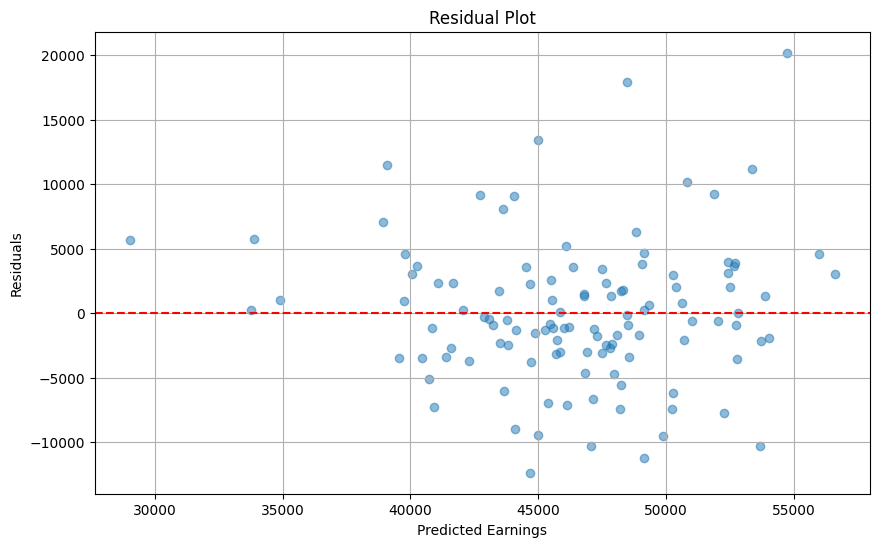

In [5]:
# prompt: error plot for this.

residuals = model.resid

# Create the residual plot
plt.figure(figsize=(10, 6))
plt.scatter(df['predicted_earnings'], residuals, alpha=0.5)
plt.xlabel("Predicted Earnings")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0
plt.grid(True)
plt.show()


In [6]:
from scipy.stats import shapiro

# Assuming 'residuals' are your model residuals
stat, p = shapiro(residuals)
print('Shapiro-Wilk Statistic: %.3f, p-value: %.3f' % (stat, p))

# Interpret the results
alpha = 0.05  # Significance level
if p > alpha:
    print('Residuals appear to be normally distributed (fail to reject H0)')
else:
    print('Residuals do not appear to be normally distributed (reject H0)')

Shapiro-Wilk Statistic: 0.964, p-value: 0.003
Residuals do not appear to be normally distributed (reject H0)


In [4]:
#Try to eliminate variables with bad t-test.
independent_variables = ['Cost', 'Grad', 'City'] #Drop Debt, bad t-test score

# Create the regression formula
formula = f"{dependent_variable} ~ {' + '.join(independent_variables)}"

# Fit the OLS model
model = smf.ols(formula, data=df).fit()

# Print the regression summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               Earnings   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     27.23
Date:                Thu, 03 Apr 2025   Prob (F-statistic):           2.67e-13
Time:                        08:55:22   Log-Likelihood:                -1164.9
No. Observations:                 116   AIC:                             2338.
Df Residuals:                     112   BIC:                             2349.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.831e+04   3318.146      5.517      0.0

In [11]:
# prompt: how to force intercept = 0

independent_variables = ['Cost', 'Grad', 'Debt', 'City']
#Drop Intercept
formula = f"{dependent_variable} ~ {' + '.join(independent_variables)} +0"
# or using "-1", formula = f"{dependent_variable} ~ {' + '.join(independent_variables)} -1"

# the formula is to drop Intercept, the co-efficient show too high initial value.
new_model = smf.ols(formula, data=df).fit()

print(new_model.summary())


                                 OLS Regression Results                                
Dep. Variable:               Earnings   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.986
Method:                 Least Squares   F-statistic:                              1973.
Date:                Thu, 03 Apr 2025   Prob (F-statistic):                   8.31e-103
Time:                        09:02:05   Log-Likelihood:                         -1165.0
No. Observations:                 116   AIC:                                      2338.
Df Residuals:                     112   BIC:                                      2349.
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

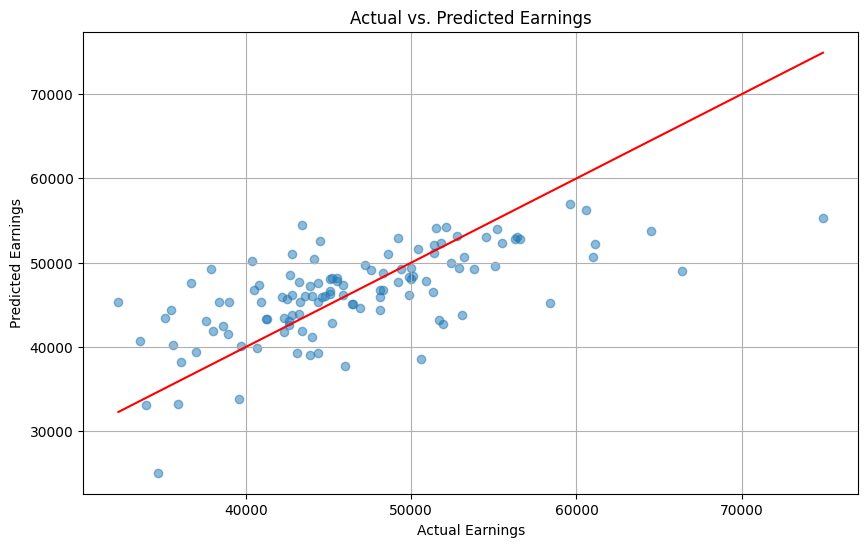

In [6]:
# Predict the dependent variable using the fitted model
df['predicted_earnings1'] = new_model.predict(df)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(df[dependent_variable], df['predicted_earnings1'], alpha=0.5)
plt.xlabel(f"Actual {dependent_variable}")
plt.ylabel(f"Predicted {dependent_variable}")
plt.title(f"Actual vs. Predicted {dependent_variable}")
plt.plot([min(df[dependent_variable]), max(df[dependent_variable])], [min(df[dependent_variable]), max(df[dependent_variable])], color='red') # Add a diagonal line for reference
plt.grid(True)
plt.show()


In [7]:
df.head()

,School,Earnings,Cost,Grad,Debt,City,predicted_earnings,predicted_earnings1
0,St. Ambrose C (NC),44800,22920,62,88,1,45992.202585,46084.343690
1,"Albion College (Albion, MI)",45100,23429,73,92,0,46211.786113,46271.321791
2,"Alfred University (Alfred, NY)",42300,19567,63,87,0,42043.768384,41769.535959
3,"Allegheny College (Meadville, PA)",49200,25147,78,92,0,47849.462585,47727.469700
4,"Beloit College (Beloit, WI)",37900,21979,78,93,1,49139.922742,49270.786956


Note that when dropping Intercept the R2 will be based on different basis (uncertered on mean) than the normal case, so they are not comparable.